# Import and load data

This notebook shows the family distribution in the dataset and the balance per family. 

In [10]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("../data/ArchiveII.csv")
SUBSAMPLED_PATH = Path("../results/ArchiveII_subsampled_ids.csv") 

full_ds = pd.read_csv(DATA_PATH) 
ss_ds = pd.read_csv(SUBSAMPLED_PATH)
ss_ds

,id,partition,fam
0,tmRNA_Ther.ther._Y15063_1-349,full,tmRNA
1,tmRNA_Shig.dyse._TRW-358708_1-363,full,tmRNA
2,tRNA_tdbR00000471-Oryctolagus_cuniculus-9986-V...,full,tRNA
3,srp_Caen.eleg._AY948608,full,srp
4,srp_Bruc.suis._AE014291,full,srp
...,...,...,...
15764,srp_Geob.kaus._BA000043,randS100,srp
15765,srp_Myco.pneu._AE000044,randS100,srp
15766,tmRNA_Ocea.ihey._BA000028_1-364,randS100,tmRNA
15767,srp_Desu.vulg._CP000527,randS100,srp


# Process, create tables and functions

In [23]:
datasets = {"100": ss_ds.query("partition == 'randS100'"),
            "200": ss_ds.query("partition == 'randS200'"),
            "400": ss_ds.query("partition == 'randS400'"),
            "full": full_ds }

sizes_percent = [ 
    len(data) / len(full_ds) * 100 
    for data in datasets.values()
    ]

labels = {
    name: f"    {name}       \n ({len(data)} seqs)"
    for name, data in datasets.items()
}

pivot_df = pd.DataFrame({
    labels[name]: data["fam"].value_counts()
    for name, data in datasets.items()
}).T

pivot_df_percent = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

labels = list(labels.values())
family_order = ['5s', '23s', 'tmRNA', 'grp1', 'tRNA', '16s',
                'srp', 'RNaseP', 'telomerase']

In [24]:
def plot_dataset_distributions() -> None:
    fig, ax = plt.subplots(figsize=(15, 8))

    # Plot the stacked bar chart
    stacked = pivot_df_percent.loc[labels, family_order].plot(
        kind="barh", stacked=True, legend=False, ax=ax
    )
    # Add percentage labels to each segment of the stacked bars
    for container in stacked.containers:
        stacked.bar_label(
            container, label_type="center", fmt="%.1f%%", fontsize=13
        )
    # Add a background bar to represent the full dataset
    ax.barh(
        range(len(labels)), sizes_percent,
        color="black", alpha=0.15, height=0.85
    )
    # Add text labels for the percentage of the full dataset
    for i, value in enumerate(sizes_percent):
        text = f"{value:.0f}%" + (
            "" if value == 100 else " of the full dataset"
        )
        ax.text(value + 0.7, i + 0.32, text, va="center", fontsize=14)

    ax.set_ylabel("Threshold", fontsize=14)
    ax.grid(axis="x", linestyle="--")
    ax.tick_params(axis="both", labelsize=12)

    handles, families = stacked.get_legend_handles_labels()
    counts = full_ds["fam"].value_counts()
    legend_labels = [f"{fam} ({counts[fam]})" for fam in families]

    fig.legend(
        handles, legend_labels,
        title="Families (count)",
        bbox_to_anchor=(0.55, -0.1),
        loc="lower center",
        ncol=5,
        frameon=False,
        fontsize=12,
        title_fontsize=14,
    )

    fig.tight_layout()
    plt.show()

# Dataset family distribution

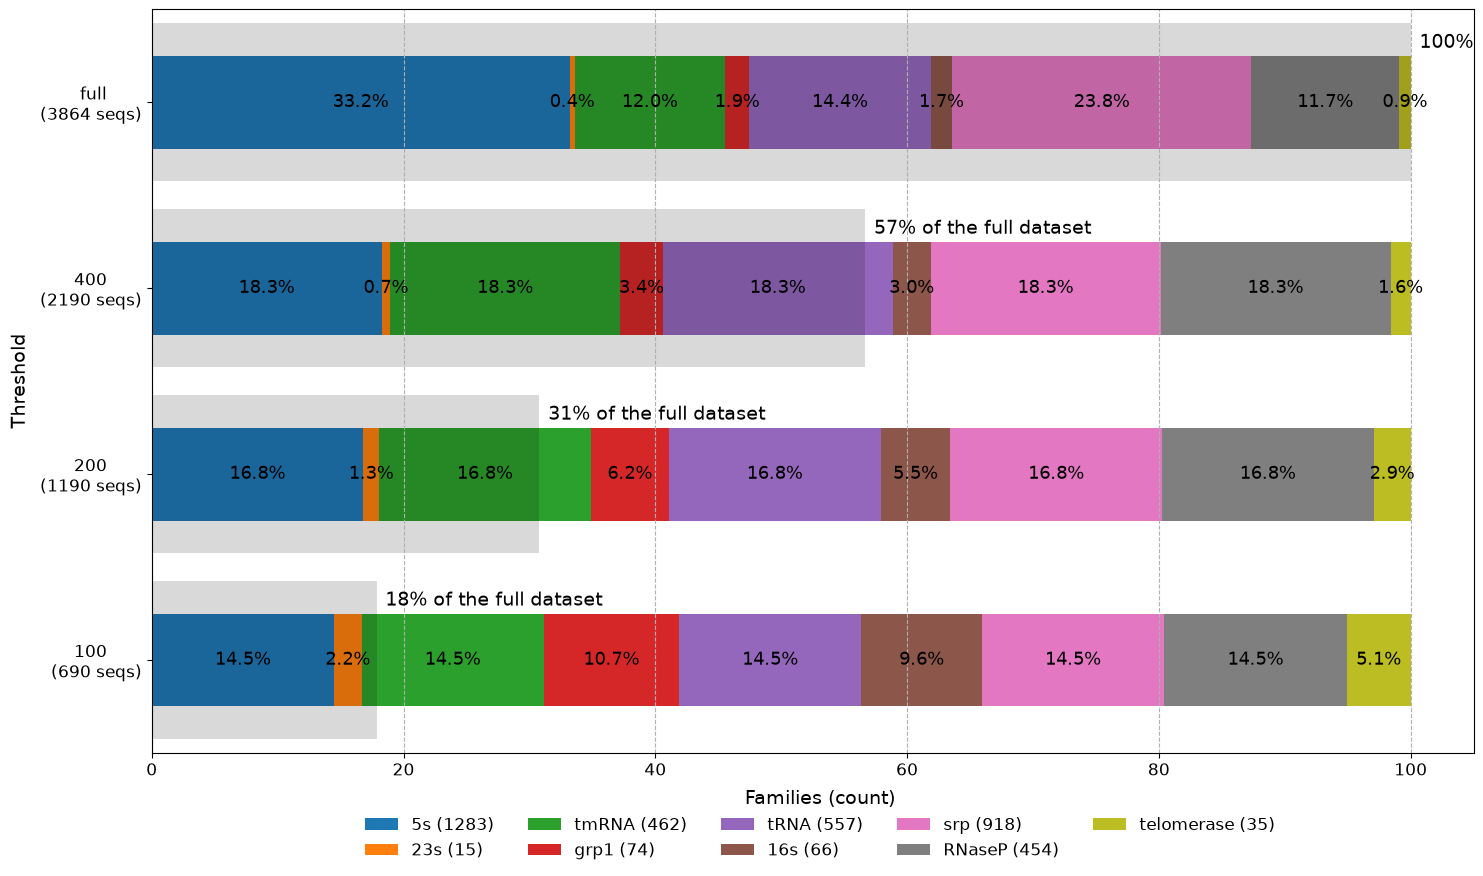

In [25]:
plot_dataset_distributions()